# Identifiering av desinformation med hjälp av maskininlärning

## Inledning

Informationspåverkan och desinformation har blivit ett växande samhällsproblem. Genom sociala medier kan information spridas mycket snabbt och nå stora grupper människor. Syftet med detta projekt är att undersöka hur maskininlärning kan användas för att identifiera potentiell desinformation.

## Mission

Projektet utgår från ett socialt entreprenörskapsperspektiv (Social Entrepreneurship). Syftet är att bidra till att motverka spridningen av desinformation genom att utveckla ett verktyg som kan hjälpa användare att bedöma trovärdigheten hos digitala nyhetsartiklar.


## Empathize

För att få en bättre förståelse för problemet genomfördes semistrukturerade intervjuer med tre personer om hur de bedömer information på sociala medier och i digitala nyhetskanaler.

Intervjuperson 1 uppgav att hen vanligtvis kontrollerar källan och jämför information från flera nyhetskällor innan hen avgör om informationen är trovärdig.

Intervjuperson 2 berättade att det ibland är svårt att avgöra vad som är sant, särskilt när information sprids snabbt på sociala medier. Personen uttryckte ett behov av ett enkelt verktyg som kan ge stöd vid bedömning av nyheter.

Intervjuperson 3 uppgav att hen tidigare har trott på falsk information på internet och önskar ett verktyg som snabbt kan indikera om en artikel verkar trovärdig eller potentiellt vilseledande.

### Sammanfattande insikter

* Användare har svårt att avgöra om information är trovärdig.
* Många förlitar sig på egna efterforskningar och källkontroll.
* Det finns ett behov av ett enkelt och lättillgängligt stöd för att bedöma nyhetsartiklar.

Insikterna från intervjuerna bidrog till beslutet att utveckla en AI-baserad applikation där användaren kan klistra in en nyhetsartikel och få en indikation på om texten liknar trovärdig information eller desinformation.


| Intervjuperson | Huvudsaklig insikt               |
| -------------- | -------------------------------- |
| Person 1       | Kontrollerar flera källor        |
| Person 2       | Svårt att avgöra vad som är sant |
| Person 3       | Önskar ett enkelt hjälpverktyg   |


### Exempel på citat från intervjuerna

**Intervjuperson 1:**
"Jag brukar kontrollera flera nyhetskällor innan jag litar på en artikel."

**Intervjuperson 2:**
"Det är svårt att veta vad som är sant när samma nyhet delas överallt på sociala medier."

**Intervjuperson 3:**
"Jag skulle gärna använda ett enkelt verktyg som kan hjälpa mig att avgöra om en artikel verkar trovärdig eller inte."


### Analys av intervjuresultaten

Intervjuerna visade att samtliga deltagare upplevde det som svårt att avgöra om information på internet är trovärdig. Flera av deltagarna uppgav att de försöker kontrollera flera källor, men att detta är tidskrävande och inte alltid möjligt.

Ett återkommande tema i intervjuerna var behovet av ett enkelt och lättillgängligt verktyg som kan ge stöd vid bedömning av nyhetsartiklar. Resultaten från intervjuerna bidrog därför till beslutet att utveckla en interaktiv applikation som med hjälp av maskininlärning kan indikera om en artikel liknar trovärdig information eller desinformation.


## Bilaga – Intervjufrågor

1. Hur avgör du om en nyhet är trovärdig?
2. Har du någon gång trott på falsk information online?
3. Skulle du använda ett verktyg som hjälper till att identifiera desinformation?

## Define

Problemformulering:
Hur kan vi hjälpa användare att identifiera potentiell desinformation i digitala nyhetsartiklar?

## Målgrupp

Den primära målgruppen för applikationen är personer som konsumerar nyheter via internet och sociala medier och som behöver stöd för att bedöma om information är trovärdig eller potentiellt vilseledande.

## Ideate

Flera lösningar diskuterades, exempelvis en faktagranskningswebbplats, ett browser-plugin och en AI-baserad klassificeringsmodell. Den valda lösningen blev en interaktiv webbapplikation utvecklad i Streamlit.

## Databearbetning

Först märktes artiklarna med etiketter:
- Fake = 1
- True = 0
Därefter slogs dataseten samman.

## Dataset

Projektet använder datasetet "Fake and Real News Dataset" från Kaggle. Datasetet innehåller cirka 45 000 nyhetsartiklar som klassificerats som antingen falska eller riktiga. Datasetet användes för att träna en maskininlärningsmodell för att identifiera potentiell desinformation.

In [10]:
df.shape

(44898, 5)

In [11]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [13]:
X = df["text"]
y = df["label"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

In [17]:
predictions = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9864142538975501


## Maskininlärningsanalys

För att identifiera potentiell desinformation användes en Logistic Regression-modell.

Datasetet delades upp i:

- 80 % träningsdata
- 20 % testdata

Modellen uppnådde en accuracy på 98,64 %.

Resultatet visar att modellen kan identifiera mönster som skiljer falska nyhetsartiklar från riktiga nyhetsartiklar med hög träffsäkerhet.

## Resultat

Modellen uppnådde en accuracy på 98,64 %, vilket visar att modellen kunde skilja mellan riktiga och falska nyhetsartiklar med hög träffsäkerhet.

## Prototype

En prototyp utvecklades i Streamlit för att skapa en interaktiv tjänst där användaren kan klistra in en nyhetsartikel och få en bedömning av om texten liknar trovärdig information eller desinformation.

Applikationen bygger på en maskininlärningsmodell som tränades på cirka 45 000 nyhetsartiklar från datasetet "Fake and Real News Dataset". Prototypen utvecklades iterativt och förbättrades genom testning och felsökning.

In [3]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake["label"] = 1
true["label"] = 0

In [7]:
df = pd.concat([fake, true], ignore_index=True)

In [8]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [9]:
df["label"].value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[4198,   49],
       [  73, 4660]])

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4247
           1       0.99      0.98      0.99      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [20]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [22]:
import os
os.listdir()

['.copilot',
 '.ipynb_checkpoints',
 '.ipython',
 '.streamlit',
 'app.py',
 'db',
 'Fake.csv',
 'find',
 'model.pkl',
 'rapport.ipynb',
 'True.csv',
 'vectorizer.pkl']

In [24]:
%%writefile app.py

import streamlit as st
import pickle

model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

st.title("Misinformation Monitor")

text = st.text_area("Klistra in en nyhetsartikel")

if st.button("Analysera"):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)

    if prediction[0] == 1:
        st.error("Artikeln liknar desinformation.")
    else:
        st.success("Artikeln liknar trovärdig information.")

Overwriting app.py


In [2]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

In [5]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [6]:
prediction = model.predict(
    vectorizer.transform([true["text"].iloc[0]])
)

print(prediction)

[0]


In [7]:
prediction = model.predict(
    vectorizer.transform([fake["text"].iloc[0]])
)

print(prediction)

[1]


## Test

Applikationen testades genom att använda artiklar från både True.csv och Fake.csv samt genom användartester där feedback samlades in kring applikationens funktionalitet och användarvänlighet.

När en artikel från True.csv användes klassificerades den som trovärdig information. När en artikel från Fake.csv användes klassificerades den som desinformation. Detta visar att modellen fungerade korrekt på de testade exemplen.

Modellen uppnådde dessutom en accuracy på 98,64 %, vilket visar att modellen presterade mycket bra på testdatan och hade en hög förmåga att skilja mellan riktiga och falska nyhetsartiklar.

Under användartesterna framkom att användarna önskade tydligare återkoppling på resultatet och en enklare användarupplevelse. Utifrån feedbacken justerades prototypen genom att skapa ett enkelt gränssnitt med en tydlig textruta och lättförståeliga meddelanden som "Artikeln liknar trovärdig information" respektive "Artikeln liknar desinformation". Användarna efterfrågade även möjligheten att snabbt kunna testa olika artiklar, vilket beaktades i den slutliga utformningen av applikationen.


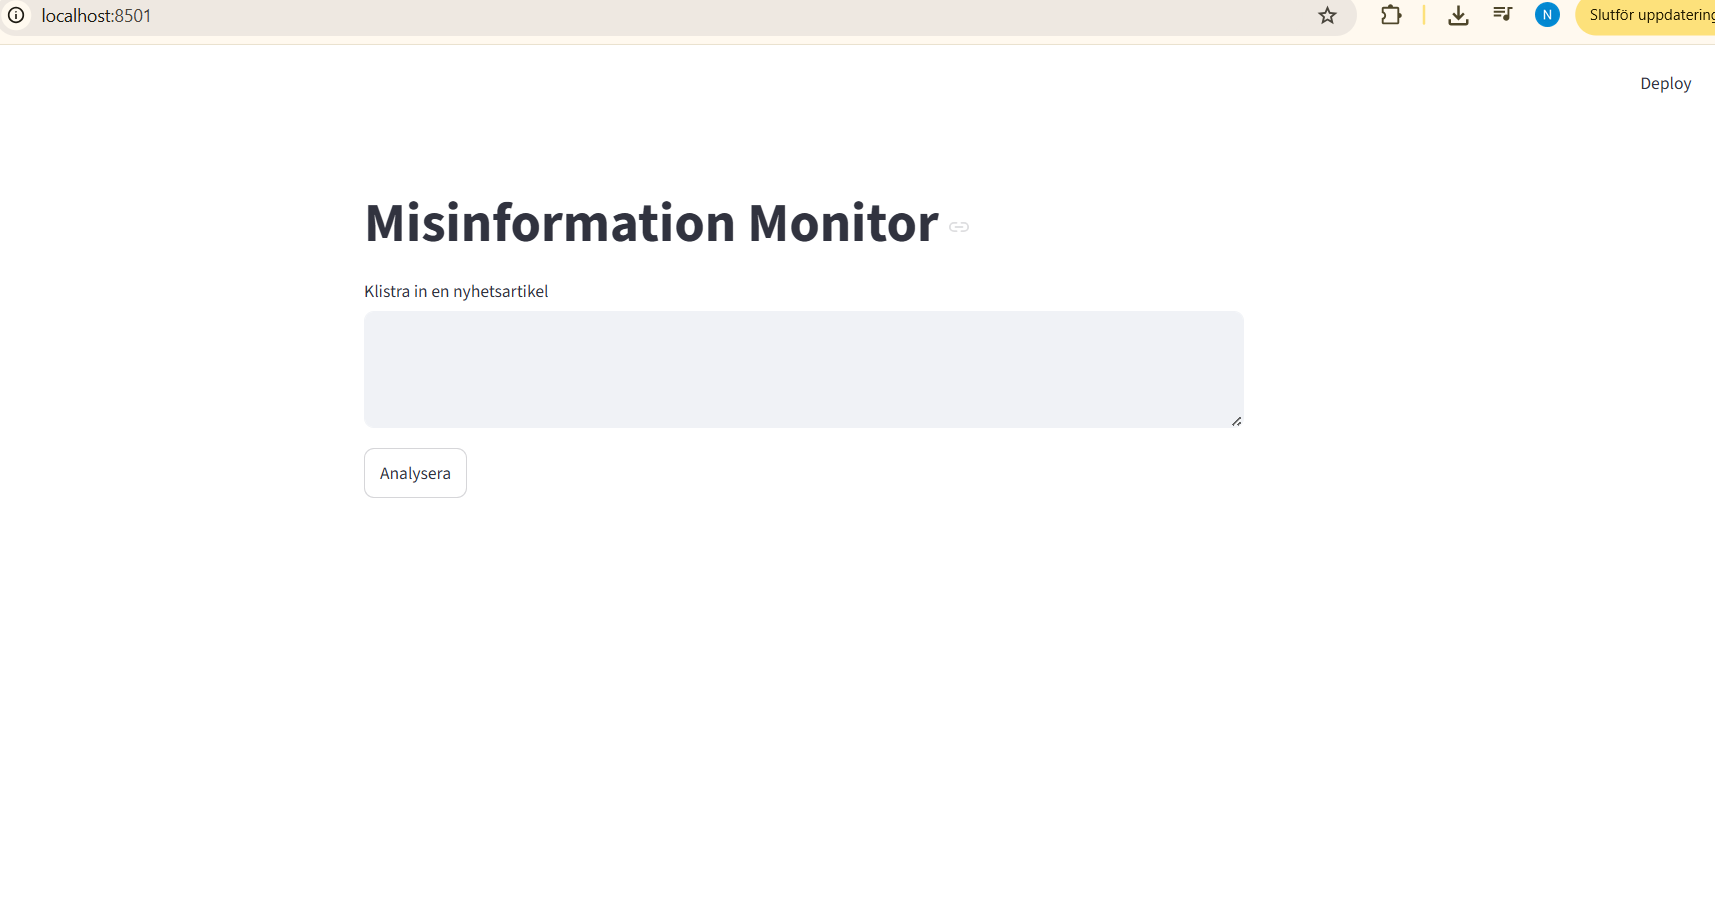

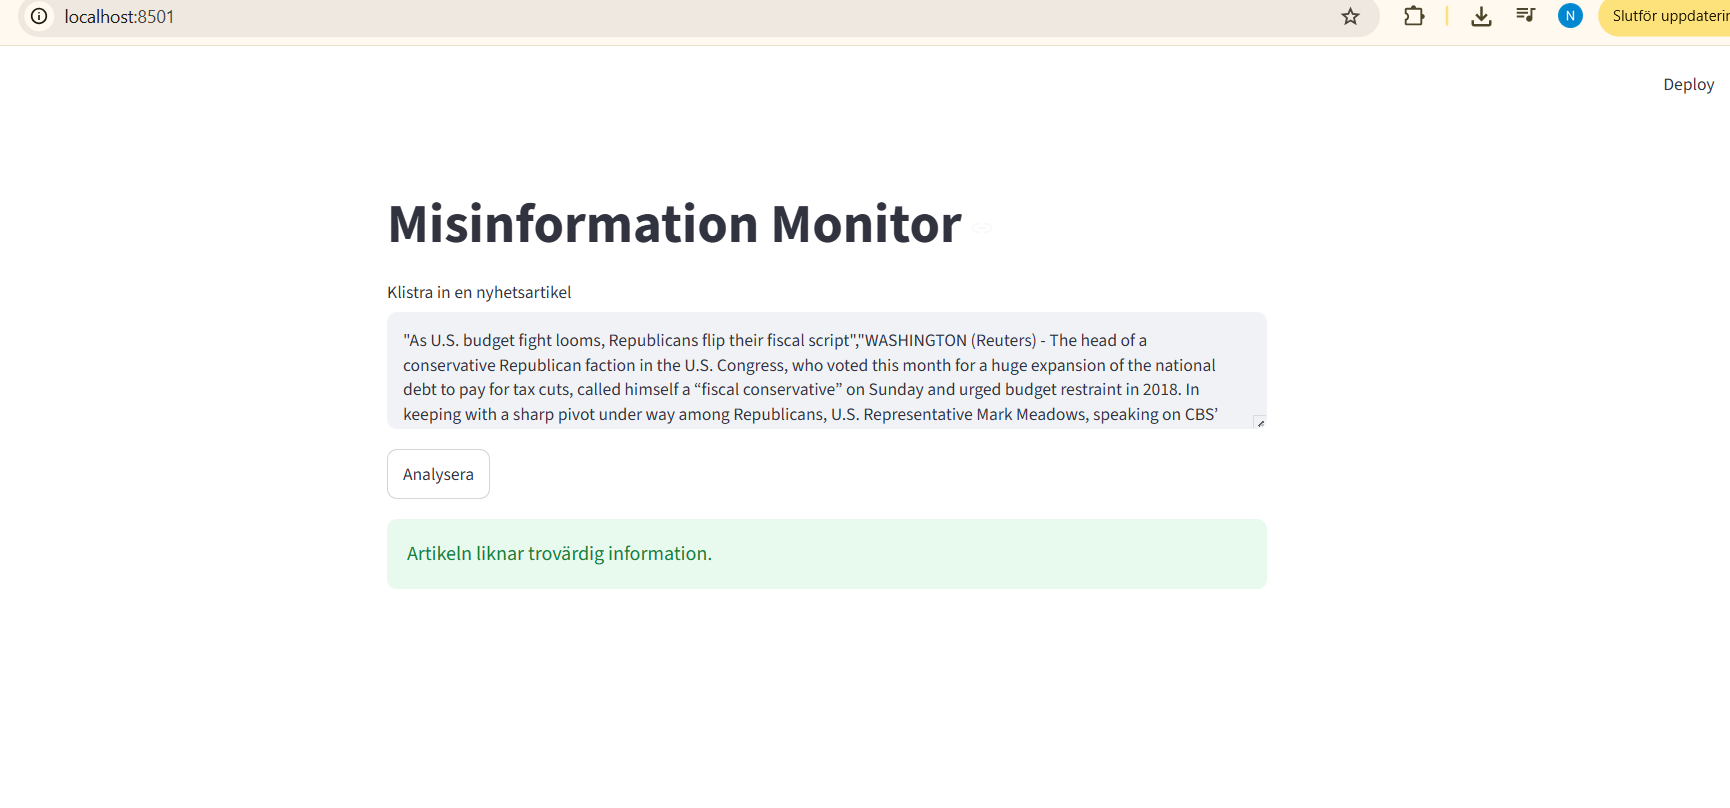

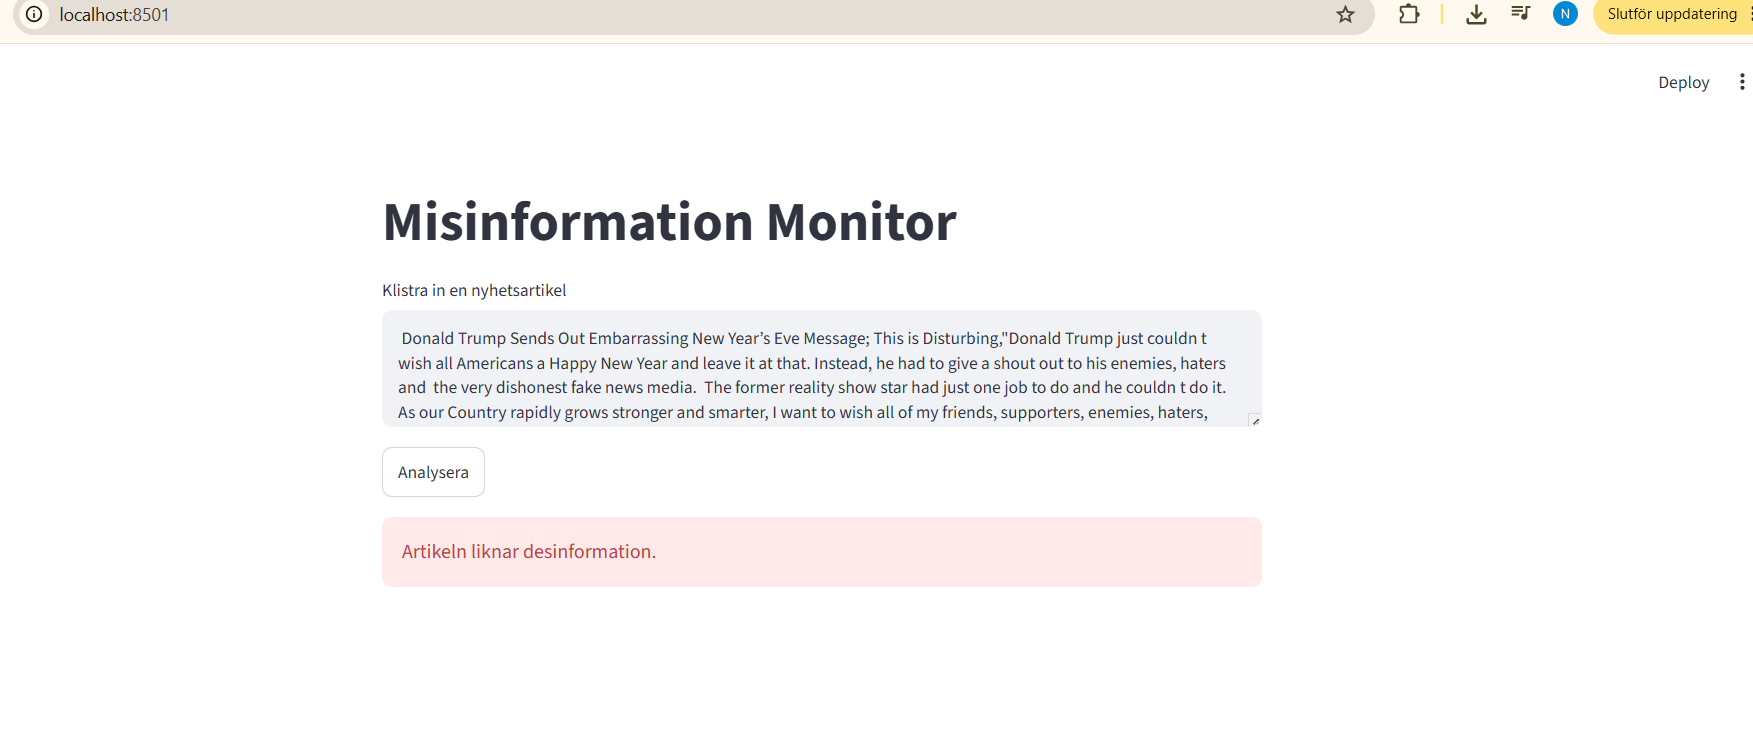

## Diskussion

Projektet visar att maskininlärning kan användas för att identifiera mönster i desinformation med hög träffsäkerhet. Modellen presterade mycket bra på hela nyhetsartiklar.

Samtidigt observerades att modellen hade svårare att klassificera mycket korta texter och enstaka meningar. Detta beror sannolikt på att modellen tränades på längre artiklar och därför behöver mer kontext för att göra tillförlitliga bedömningar.

En möjlig vidareutveckling av projektet skulle vara att använda större språkmodeller (LLM) eller mer avancerade klassificeringsmetoder för att förbättra prestandan ytterligare.

### Begränsningar och framtida arbete

Modellen tränades på engelskspråkiga nyhetsartiklar och resultaten kan därför variera för andra typer av texter, exempelvis mycket korta inlägg eller texter på andra språk. En möjlig vidareutveckling är att träna modellen på fler datakällor och undersöka mer avancerade metoder, såsom transformerbaserade språkmodeller.


## Slutsats

Syftet med projektet var att utveckla en data-driven tjänst som kan hjälpa användare att identifiera potentiell desinformation i nyhetsartiklar.

Resultaten visar att den utvecklade modellen lyckades klassificera riktiga och falska nyhetsartiklar med hög träffsäkerhet och att den interaktiva Streamlit-applikationen fungerar som ett stöd för att bedöma informationens trovärdighet.

Projektet visar därmed hur maskininlärning och dataanalys kan användas för att bidra till att motverka spridningen av desinformation.

## Design Thinking-verktyg

Följande verktyg användes under de olika stegen i Design Thinking-processen:

| Steg      | Verktyg                           |
| --------- | --------------------------------- |
| Empathize | Semistrukturerade intervjuer      |
| Define    | Problem Statement / Point-of-View |
| Ideate    | Brainstorming                     |
| Prototype | Streamlit-prototyp                |
| Test      | Användartest och feedback         |
